In [37]:
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
from scipy.stats import poisson
from scipy.stats import expon

In [38]:
survey_1 = [35, 36, 33, 37, 34, 35]
np.mean(survey_1)

np.float64(35.0)

In [39]:
survey_2 = [20, 37, 17, 50, 53, 33]
np.mean(survey_2)

np.float64(35.0)

In [40]:
np.mean(survey_1), np.median(survey_1),np.mean(survey_2), np.median(survey_2)

(np.float64(35.0), np.float64(35.0), np.float64(35.0), np.float64(35.0))

In [41]:
n = 6
bootstrapped_samples_1 = np.random.choice(survey_1, size=n)
bootstrapped_samples_1

array([37, 36, 33, 37, 37, 35])

In [42]:
np.median(bootstrapped_samples_1)

np.float64(36.5)

In [43]:
bootstrapped_samples_2 = np.random.choice(survey_2, size=n)
bootstrapped_samples_2

array([33, 53, 20, 33, 53, 53])

<Axes: ylabel='Count'>

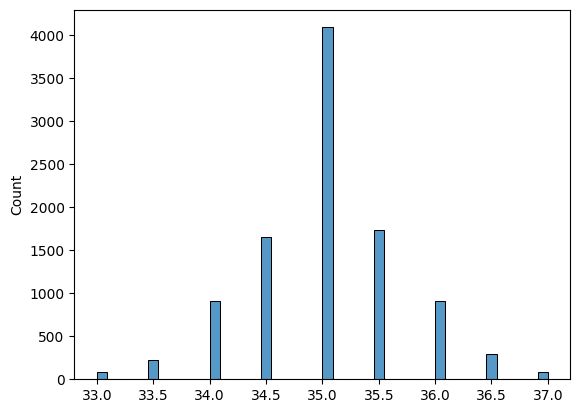

In [44]:
bootstrapped_median_survey_1 = []
for reps in range(10000):
    bootstrapped_samples = np.random.choice(survey_1, size=n)
    bootstrapped_median = np.median(bootstrapped_samples)
    bootstrapped_median_survey_1.append(bootstrapped_median)

sns.histplot(bootstrapped_median_survey_1)

<Axes: ylabel='Count'>

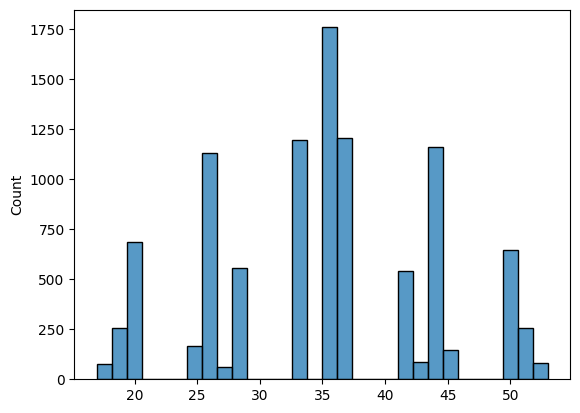

In [45]:
bootstrapped_median_survey_2 = []
for reps in range(10000):
    bootstrapped_samples = np.random.choice(survey_2, size=n)
    bootstrapped_median = np.median(bootstrapped_samples)
    bootstrapped_median_survey_2.append(bootstrapped_median)

sns.histplot(bootstrapped_median_survey_2)

In [46]:
## Now how to calculate the CI from here.

x1 = np.percentile(bootstrapped_median_survey_1, 2.5)
x2 = np.percentile(bootstrapped_median_survey_1, 97.5)

x1, x2

(np.float64(33.5), np.float64(36.5))

In [47]:
# calculate the CI for survey_2
x1 = np.percentile(bootstrapped_median_survey_2, 2.5)
x2 = np.percentile(bootstrapped_median_survey_2, 97.5)
x1, x2

(np.float64(18.5), np.float64(51.5))

Poisson Distribution (PMF)

In [48]:
# Q. What is the probability of exactly 25 vehicles passing through the toll booth in the next hour?
# Q. What is the probability of more than 40 vehicles passing through the toll booth in the next hour?

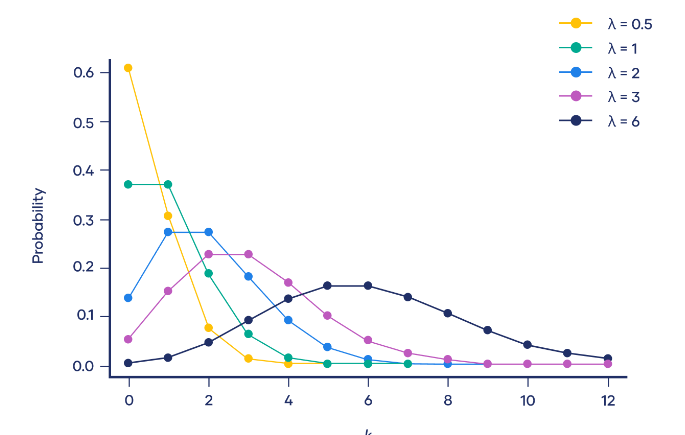

Q. What is the prob of exactly 20 errors in log file for a particular server in the next 10 hours?

In [49]:
# ##
# suppose a particular hospital experiences an average of 2 births per hour.
# We can use the formula above to determine
# the probability of experiencing 0, 1, 2, 3 births, etc. in a given hour:

In [50]:
# P(X=0)
poisson.pmf(mu=2,k=0)

np.float64(0.1353352832366127)

In [51]:
poisson.pmf(mu=2,k=1)

np.float64(0.2706705664732254)

In [52]:
poisson.pmf(mu=2,k=2)

np.float64(0.2706705664732254)

In [53]:
poisson.pmf(mu=2,k=3)

np.float64(0.18044704431548356)

In [54]:
# It is given a website receive 10 messages per hour. what is the probability of receiving 8 messages in the next hour? 
# P(X=8)
poisson.pmf(mu=10,k=8)

np.float64(0.11259903214902009)

Imagine we have collected data for all the football matches ever happened, now we want to analyze the distribution of goals.

We observe that the average goal per 90 mins match is 2.5

So the rate will be 2.5 goals per match (λ = 2.5).

Q. If I want to know the probability of getting 1 goal in last 30 mins?

In [55]:
#  on average goal 90 mins for 2.5
# which means average goal per minute is 2.5/90
# which means rate for 30 minute is (2.5/90)*30
rate =2.5/3
rate

0.8333333333333334

In [56]:
poisson.pmf(mu=rate,k=1)

np.float64(0.3621651737558985)

There are 80 students in a kinder garden class. Each one of them has 0.015 probability of forgetting their lunch on any given day.

(a) What is the average or expected number of students who forgot lunch in the class?
(b) What is the probability that exactly 3 of them will forget their lunch today?

In [57]:
# (a) What is the average or expected number of students who forgot lunch in the class?
# E=n*p
E=80*0.015
E

1.2

In [58]:
# (b) What is the probability that exactly 3 of them will forget their lunch today?
from scipy.stats import binom
binom.pmf(n=80,p=0.015,k=3)

np.float64(0.08660120920447557)

In [59]:
# (b) What is the probability that exactly 3 of them will forget their lunch today?
poisson.pmf(mu=1.2,k=3)

np.float64(0.08674393303071422)

### Observation: Poisson approximates to binomial when the probability is less < 0.05 and n>=20

You receive 240 messages per hour on average - assume Poisson distributed. Rate of messages arriving per second is (1/15)

What is the probability of having no message in 10 seconds?

1 sec ----- 1/15 # Rate

10 sec-----10/15 # Rate for 10 sec

In [60]:
poisson.pmf(mu=10/15,k=0)

np.float64(0.513417119032592)

What is the probability of waiting for more than 10 seconds for the next message?

In [61]:
# it is same as above question that the no messages in 10 minutes
# P(T>10) is Continuous distribution 


# e^(-10*rate)
#  scale = 1/rate
# rate = 1/15

rate = 1/15
scale = 1/rate # 15
p_wait_more_than_10 = expon.sf(10, scale=scale)
p_wait_more_than_10


np.float64(0.513417119032592)

# Poisson distribution measures the number of events
# in this Exponential distribution measures the time

### ___________________________________________________________

# In Poisson the rate is denoted as lambda 
# In Exponential the rate is denoted as beta 

## beta = 1/lambda

In [11]:
#  What is the probability of waiting less than or equal to 10 seconds?
# P(T<=10)

expon.cdf(x=10, scale=scale)


np.float64(0.486582880967408)

If electricity power failures occur according to a poisson distribution with an average of three failures every 20 weeks.

Calculate the probability that there will not be more than one power failure during a week.


(Round off the values to 4 decimal points)

In [2]:
# 3 failures in 20 weeks
# per week is 3/20
# P(x<=1)
from scipy.stats import poisson
poisson.cdf(k=1, mu=3/20)

np.float64(0.9898141728888165)

Q2

An observer counts 240 vehicles per hour (3600 seconds) at a specific vehicle arrival location on a highway.

Assume that the arrivals follow the poisson distribution, What is the probability of one vehicle arriving over a 30-second time interval?

In [7]:
#24o veh per 3600 sec
# per sec = 240/3600 = 1/15
#per 30 sec = 30/15 = 2
from scipy.stats import poisson
poisson.pmf(k=1,mu=2)

np.float64(0.2706705664732254)

Q3
A packaging factory consists of 10 printing machines. Average number of failures occurring in one printing machine per year is 0.4

(a) What is the total expected number of failures in the factory, in a year?
(b) What is the probability that there are fewer than two failures in the factory in a year?

In [11]:
rate = 10*0.4
print(f'total expected failures in a year is {rate}')

q2 = poisson.cdf(k=1,mu=rate)
print(f'Probability of at most 2 failures in a year is {q2}')

total expected failures in a year is 4.0
Probability of at most 2 failures in a year is 0.0915781944436709


A call centre receives 20 calls per hour, on an average.

a) What is the probability of receiving exactly 25 calls in a given hour?
b) What is the probability of receiving more than 25 calls in a given hour?

In [13]:
q1 = poisson.pmf(k=25,mu=20)
print(f'Probability of exactly 25 calls in an hour is {q1}')

q2 = 1-poisson.cdf(k=25,mu=20)
print(f'Probability of more than 25 calls in an hour is {q2}')

Probability of exactly 25 calls in an hour is 0.04458764910826764
Probability of more than 25 calls in an hour is 0.1121849727179699


As a data analyst at Global Mariotech, one of your prime duties is to understand customer sentiments and provide a better experience to the customers.

Based on a recent survey, it was found that there were 30% negative responses, and 70% positive.

Assuming that we pick one response after another randomly, estimate the number of feedbacks to expect, before a negative feedback appears.

In [14]:
1/0.3

3.3333333333333335

Q6
You are hired as a data scientist for the company SellMart.

Your first task is to analyze the durations of customer support call.

On an average, a customer care executive takes about 5 minutes to solve the issue of any customer. It is known that the time taken follows an exponential distribution.

Find the probability that an executive spends 4 to 5 minutes with any randomly selected customer.

In [15]:
from scipy.stats import expon
expon.cdf(5,scale=5) - expon.cdf(4,scale=5)

np.float64(0.08144952294577923)

Q7
A new pair of running shoes of Brank X are known to last 6 months, on an average, assuming that they are used every day.

It is known that the duration of their lifespan follows exponential distributed.

If a pair has already lasted 5 months, find the probability that it will last a total of over 9 months.

In [19]:
1-expon.cdf(4,scale=6)

np.float64(0.513417119032592)